# Project: Investigate Customer 360 Dataset

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#inspection">Data Inspection</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#Exploratory">Exploratory Data Analysis</a></li>
<li><a href="#viz">Data Visualizations</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#recommendations">Recommendations</a></li>
</ul>

---

<a i='intro'></a>
## Introduction
# Customer 360 Analysis Report

## Dataset Introduction
This report gives us a complete, 360-degree look at our customers. We’re exploring how users behave, how well our support team is doing, what subscriptions they prefer, and how our marketing is performing. The goal is simple: use these insights to keep customers around longer, boost revenue, and improve our services.

---

## Dependent and Independent Variables

### What we measure (Dependent Variables):
* **Total Active Accounts:** The total number of active customer profiles and subscriptions we have.

* **Average Annual Revenue:** How much money, on average, each account type brings in.

* **Ticket Rating / Response Rate:** How happy customers are based on their support feedback.

* **Converted Interactions:** How many people actually turn into users through our marketing.

### What we look at to find patterns (Independent Variables):
* **Account Status:** Whether an account is active, inactive, or suspended.

* **Subscription Plan & Billing Cycle:** Which tier they use (Business, Enterprise, Free, Professional, Starter) and how they pay (Annual, Monthly, Quarterly).

* **Geographic Location:** Where our active customers are located around the world.

* **Transaction & Priority Types:** Categories of money movement and priority levels for support or cancellations.

* **Marketing Channels:** Where we find people, like Google Ads, Facebook, referrals, emails, webinars, or LinkedIn.

---

## Research Questions

**1. What is the average annual_revenue for customers with Different Account status?**

**2. Which countries have the highest count of Active customer accounts?**

**3. Which combination of subscription plan and billing_cycle yields the highest volume of Active statuses?**

**4. What is the Response rate (rated vs. unrated tickets)?**

**5. How do ticket priority levels impact resolution_hours and customer satisfaction scores?**

**6. What is the total monetary amount generated per Transaction type (e.g., Upgrades, Add-Ons, Refunds)?**

**7. Which campaign achieved the highest number of conversions (converted = Yes) relative to its Average budget?**

**8. Which marketing channel generates the highest conversion rate?**

**9. Do customers who submit Any priority tickets have a higher rate of cancelled subscriptions?**

**10. Which subscription plan generates the most transactional activity?**

<a id='inspection'></a>
## **1. Data Inspection**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv(r'..\RawData\W4\customers.csv')
campaign_interactions = pd.read_csv(r'..\RawData\W4\campaign_interactions.csv')
marketing_campaigns = pd.read_csv(r'..\RawData\W4\marketing_campaigns.csv')
subscriptions = pd.read_csv(r'..\RawData\W4\subscriptions.csv')
support_tickets = pd.read_csv(r'..\RawData\W4\support_tickets.csv')
transactions_q1 = pd.read_csv(r'..\RawData\W4\transactions_q1.csv')
transactions_q2 = pd.read_csv(r'..\RawData\W4\transactions_q2.csv')
transactions_q3 = pd.read_csv(r'..\RawData\W4\transactions_q3.csv')
transactions_q4 = pd.read_csv(r'..\RawData\W4\transactions_q4.csv')
Tables = ['customers','campaign_interactions','marketing_campaigns','subscriptions','support_tickets','transactions_q1','transactions_q2','transactions_q3','transactions_q4']

In [3]:
for table in Tables :
    print(f"---------------Table: {table}---------------")
    display(globals()[table].sample(5))

---------------Table: customers---------------


,user_id,full_name,job_title,company_name,email_address,phone_number,address,city,country,birth_date,registration_date,last_login_date,account_status,annual_revenue
1001,1002,William Harris,Data Analyst,Morrison Consulting,michael49@example.com,(899)305-2702x599,USNV Lewis\nFPO AP 25894,Dubai,United Arab Emirates,1957-10-25,2023-08-02,2025-07-26,Suspended,626086.35
948,949,Alan Huff,Financial Analyst,Bates Technologies,james70@example.net,430.702.1027x3663,"22348 Adams Forest Apt. 660\nNew Davidtown, ME...",AMSTERDAM,Netherlands,1981-01-28,2025-10-09,2025-10-25,Suspended,317454.5
732,733,Amanda Romero,Sales Manager,Hernandez Consulting,ldavis@example.org,993-333-5937,"02956 Nicholas Ferry\nNicholasview, UT 65018",Oslo,NORWAY,1958-10-05,2023-03-01,24/02/2024,suspended,436165.45
1066,1067,Angela Perry,Marketing Manager,Smith LLC,daylee@example.net,001-984-614-2024x84350,"328 Melissa Route\nJohnsonview, KY 01013",OSLO,Sweden,1970-06-09,"May 26, 2024",2024-12-14,active,132418.54
740,741,Luis Daniels,CEO,Moore Ltd.,householly@example.com,516-276-7063x63286,"00848 Martinez Viaduct\nKerriside, IL 27317",cairo,SWEDEN,2004-04-11,2024-01-25,NaN,Inactive,90344.74


---------------Table: campaign_interactions---------------


,interaction_id,user_id,campaign_id,interaction_date,interaction_type,converted
5003,INT-0005004,1449,CMP-0009,"Feb 28, 2025",click,no
9239,INT-0009240,341,CMP-0016,13/08/2025,EMAIL OPEN,NO
7891,INT-0007892,71,CMP-0029,19/07/2025,Email Open,No
13421,INT-0013422,1080,CMP-0030,11-11-2025,Impression,No
6911,INT-0006912,322,CMP-0009,"Aug 05, 2025",Website Visit,No


---------------Table: marketing_campaigns---------------


...

,transaction_id,user_id,transaction_date,transaction_amount,payment_method,transaction_type
2770,Q2-TX-002771,663,2025-05-03,99.86 USD,Bank Transfer,UPGRADE
2745,Q2-TX-002746,254,"May 11, 2025",$-263.79,PayPal,Refund
2176,Q2-TX-002177,931,"May 15, 2025",240.25,Debit Card,Add-on
2291,Q2-TX-002292,900010,2025-06-11,$62,PayPal,ADD-ON
821,Q2-TX-000822,1458,04/05/2025,-126.81,Debit Card,Refund


---------------Table: transactions_q3---------------


,transaction_id,user_id,transaction_date,amount,payment_type,transaction_type,source_system
1854,Q3-TX-001855,1148,16-08-2025,206.05,Debit Card,Upgrade,Legacy Billing
2320,Q3-TX-002321,1339,2025-09-07,458.56,PayPal,Subscription,Legacy Billing
2187,Q3-TX-002188,401,"Aug 18, 2025",$338.75,DEBIT CARD,Add-on,Legacy Billing
1397,Q3-TX-001398,534,2025-09-23,242.76,Credit Card,subscription,Legacy Billing
1728,Q3-TX-001729,461,2025-09-15,-93.01 USD,Bank Transfer,REFUND,Legacy Billing


---------------Table: transactions_q4---------------


,transaction_id,user_id,transaction_date,transaction_amount,payment_type,transaction_type,currency
1303,Q4-TX-001304,1115,"Dec 07, 2025",175.96,Credit Card,Upgrade,USD
2957,Q4-TX-002958,588,10/22/2025,-296.88,Credit Card,refund,usd
539,Q4-TX-000540,459,10/11/2025,$191,debit card,Upgrade,usd
1541,Q4-TX-001542,464,10/11/2025,-152.29 USD,Credit Card,Refund,USD
294,Q4-TX-000295,7,2025-11-16,$595,credit card,Upgrade,USD


In [4]:
for table in Tables :
    print(f"---------------Table: {table}---------------")
    display(globals()[table].info())

---------------Table: customers---------------
<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1575 non-null   int64
 1   full_name          1575 non-null   str  
 2   job_title          1575 non-null   str  
 3   company_name       1507 non-null   str  
 4   email_address      1548 non-null   str  
 5   phone_number       1535 non-null   str  
 6   address            1575 non-null   str  
 7   city               1575 non-null   str  
 8   country            1575 non-null   str  
 9   birth_date         1575 non-null   str  
 10  registration_date  1575 non-null   str  
 11  last_login_date    1499 non-null   str  
 12  account_status     1575 non-null   str  
 13  annual_revenue     1535 non-null   str  
dtypes: int64(1), str(13)
memory usage: 172.4 KB


None

---------------Table: campaign_interactions---------------
<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   interaction_id    15100 non-null  str  
 1   user_id           15100 non-null  int64
 2   campaign_id       14884 non-null  str  
 3   interaction_date  15100 non-null  str  
 4   interaction_type  15100 non-null  str  
 5   converted         15100 non-null  str  
dtypes: int64(1), str(5)
memory usage: 707.9 KB


None

---------------Table: marketing_campaigns---------------
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   campaign_id    32 non-null     str  
 1   campaign_name  32 non-null     str  
 2   channel        32 non-null     str  
 3   campaign_type  32 non-null     str  
 4   start_date     32 non-null     str  
 5   budget         32 non-null     str  
dtypes: str(6)
memory usage: 1.6 KB


...

None

---------------Table: transactions_q3---------------
<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_id    3025 non-null   str  
 1   user_id           3025 non-null   int64
 2   transaction_date  3025 non-null   str  
 3   amount            2971 non-null   str  
 4   payment_type      3025 non-null   str  
 5   transaction_type  3025 non-null   str  
 6   source_system     3025 non-null   str  
dtypes: int64(1), str(6)
memory usage: 165.6 KB


None

---------------Table: transactions_q4---------------
<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   transaction_id      3025 non-null   str  
 1   user_id             3025 non-null   int64
 2   transaction_date    3025 non-null   str  
 3   transaction_amount  2948 non-null   str  
 4   payment_type        3025 non-null   str  
 5   transaction_type    3025 non-null   str  
 6   currency            3025 non-null   str  
dtypes: int64(1), str(6)
memory usage: 165.6 KB


None

In [5]:
#Function to get all important information needs for cleaning
def Data_info (df):
    print(f'Null Values in dataset are:\n{df.isna().sum()[df.isna().sum() > 0]}')
    print('-' * 40)
    print(f'Duplicated Values in dataset are: {df.duplicated().sum()}')
    print('-' * 40)
    print(f'Data Types in dataset are:\n{df.dtypes}')

In [6]:
# Data_info(customers)
# Data_info(campaign_interactions)
# Data_info(marketing_campaigns)
Data_info(subscriptions)

Null Values in dataset are:
end_date       4624
monthly_fee       2
discount        282
dtype: int64
----------------------------------------
Duplicated Values in dataset are: 69
----------------------------------------
Data Types in dataset are:
subscription_id      str
user_id            int64
plan                 str
billing_cycle        str
start_date           str
end_date             str
monthly_fee          str
discount             str
status               str
dtype: object


<a id='wrangling'></a>
## **2. Data Wrangling**

In [7]:
# Customer Table Cleaning 
def cust_cleaner(df):
    #Removing phone_number & address column 
    df = df.drop(columns=['phone_number', 'address'])

    #Formatting email column
    df['email_address'] = df['email_address'].str.lower().str.strip()

    #Formatting JopTitle column & Change Type to Category
    df['job_title'] = df['job_title'].astype('category')

    #Formatting multiple columns & Change Types to Category
    for col in ['city','country','account_status'] :
        df[col] = df[col].str.title().str.strip().astype('category')

    #Formatting Dates columns & Change Types to DateTime
    for col in ['birth_date','registration_date','last_login_date'] :
        df[col] = pd.to_datetime(df[col],format='mixed' , errors='coerce').dt.strftime('%Y-%m-%d')

    #Removing '$', 'USD', ',' and useless spaces to help python convert it to Float
    df['annual_revenue'] = pd.to_numeric(df['annual_revenue'].str.replace('$', '').str.replace('USD', '').str.replace(',', '').str.strip(), errors='coerce')

    #Removing Duplicates After Cleaning cause different string formates leads to 0 duplicates
    df= df.drop_duplicates()
    
    #Solve all null values
    df['company_name'] = df['company_name'].fillna('Not Provided!')
    df['email_address'] = df['email_address'].fillna('Not Provided!')
    df['annual_revenue'] = df['annual_revenue'].fillna(0)
    df['last_login_date'] = df['last_login_date'].fillna(df['registration_date'])


    return df
    

In [8]:
customers = cust_cleaner(customers)
customers.sample(5)

,user_id,full_name,job_title,company_name,email_address,city,country,birth_date,registration_date,last_login_date,account_status,annual_revenue
598,599,Brooke Taylor,Marketing Manager,Bradshaw Solutions,riosgeorge@example.org,Singapore,Egypt,2000-11-18,2023-01-10,2024-06-28,Active,240144.17
1348,1349,Mary Jackson,CTO,Crosby Ltd.,ckelly@example.com,Sydney,Singapore,1963-11-05,2025-04-05,2025-09-15,Active,125892.66
606,607,Amanda Riley,Software Engineer,Reynolds PLC,jennifersmith@example.org,Berlin,Canada,1955-10-16,2024-12-30,2025-03-20,Inactive,190679.17
840,841,Maria Peck,HR Manager,Griffin Holdings,ljohnson@example.org,Singapore,Italy,1964-02-19,2025-12-23,2025-12-24,Inactive,316593.98
819,820,Kimberly Davis,Marketing Manager,Bell Ltd.,brandi07@example.org,Riyadh,Brazil,1973-04-06,2023-03-19,2024-11-19,Suspended,690959.34


In [9]:
# campaign_interactions Table Cleaning 
def camp_inter_cleaner (df):
    #Formatting interaction_type & converted column
    for col in ['interaction_type', 'converted']:
        df[col] = df[col].str.title().str.strip().astype('category')

    #Formatting Dates columns & Change Types to DateTime
    df['interaction_date'] = pd.to_datetime(df['interaction_date'], format='mixed',errors='coerce')

    #Removing Duplicates
    df.drop_duplicates(inplace=True)

    #Solve all null values
    df = df.fillna('No Campaign')
    return df

In [10]:
campaign_interactions = camp_inter_cleaner(campaign_interactions)
campaign_interactions.sample(5)

,interaction_id,user_id,campaign_id,interaction_date,interaction_type,converted
9841,INT-0009842,164,CMP-0016,2025-11-26,Impression,No
1923,INT-0001924,986,CMP-0026,2025-11-05,Click,No
6867,INT-0006868,1191,CMP-0001,2025-08-04,Website Visit,No
9991,INT-0009992,148,CMP-0021,2025-12-13,Impression,No
4247,INT-0004248,1123,CMP-0026,2025-04-12,Impression,Yes


In [11]:
# marketing_campaigns Table Cleaning
def marketing_cleaner(df):

    #Formatting multiple columns & Change Types to Category
    for col in ['campaign_name','channel','campaign_type'] :
        df[col] = df[col].str.title().str.strip().astype('category')

    # #Formatting Dates columns & Change Types to DateTime
    df['start_date'] = pd.to_datetime(df['start_date'],format='mixed' , errors='coerce').dt.strftime('%Y-%m-%d')

    # #Removing '$', 'USD', ',' and useless spaces to help python convert it to Float
    df['budget'] = pd.to_numeric(df['budget'].str.replace('$', '').str.replace('USD', '').str.replace(',', '').str.strip(), errors='coerce')

    df.drop_duplicates(inplace=True)

    return df

In [12]:
marketing_campaigns = marketing_cleaner(marketing_campaigns)
marketing_campaigns.sample(5)

,campaign_id,campaign_name,channel,campaign_type,start_date,budget
26,CMP-0027,Enhanced Methodical Task-Force,Referral,Acquisition,2025-12-05,30784.03
6,CMP-0007,Grass-Roots Zero-Defect Customer Loyalty,Facebook,Brand Awareness,2025-06-15,22747.53
19,CMP-0020,Pre-Emptive Bottom-Line Challenge,Webinar,Retention,2025-04-17,46114.44
24,CMP-0025,Digitized Exuding Budgetary Management,Google Ads,Brand Awareness,2025-03-15,49449.73
12,CMP-0013,Face-To-Face Client-Driven Frame,Linkedin,Upsell,2025-05-04,41726.49


In [13]:
# subscriptions Table Cleaning
def sub_cleaner(df):

    #Formatting multiple columns & Change Types to Category
    for col in ['plan','billing_cycle','status'] :
      df[col] = df[col].str.title().str.strip().astype('category')

    # Formatting Dates columns & Change Types to DateTime
    df['start_date'] = pd.to_datetime(df['start_date'], format='mixed', errors='coerce') #change it to Datetime
    df['end_date'] = pd.to_datetime(df['end_date'], format='mixed', errors='coerce').dt.strftime('%Y-%m-%d') #change it to Datetime then display it as str

    # #Removing '$', 'USD', ',' and useless spaces to help python convert it to Float
    df['monthly_fee'] = pd.to_numeric(df['monthly_fee'].str.replace('$', '').str.replace('USD', '').str.replace(',', '').str.strip(), errors='coerce')
    df['discount'] = pd.to_numeric(df['discount'].str.replace('%', '').str.strip()) / 100


    df[['monthly_fee','discount']] = df[['monthly_fee','discount']].fillna(0)
    df['end_date'] = df['end_date'].fillna('Ongoing')


    df.drop_duplicates(inplace=True)


    return df

In [14]:
subscriptions = sub_cleaner(subscriptions)
subscriptions.sample(5)

,subscription_id,user_id,plan,billing_cycle,start_date,end_date,monthly_fee,discount,status
5957,SUB-005958,1316,Professional,Annual,2025-04-18,Ongoing,150.68,0.20,Active
278,SUB-000279,205,Enterprise,Monthly,2025-08-25,2025-11-11,826.78,0.15,Cancelled
1293,SUB-001294,1244,Professional,Quarterly,2025-09-14,2026-08-14,134.12,0.15,Expired
688,SUB-000689,657,Business,Annual,2025-09-02,2026-07-13,284.57,0.15,Expired
5320,SUB-005321,1490,Professional,Annual,2025-06-08,2025-12-28,145.15,0.15,Paused


In [15]:
# support_tickets  Table Cleaning
def supp_cleaner (df):

    # Formate Datetime
    df['opened_date'] = pd.to_datetime(df['opened_date'],format='mixed',errors='coerce')
    
    # Formate strings
    for col in ['category','priority','ticket_status']:
        df[col] = df[col].str.title().str.strip().astype('category')

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # It has nulls in satisfaction column but i need to keep them to use in my analysis
    return df

In [16]:
support_tickets = supp_cleaner(support_tickets)
support_tickets.sample(5)

,ticket_id,user_id,opened_date,category,priority,resolution_hours,satisfaction,ticket_status
494,TCK-000495,914,2025-01-23,Billing,Critical,5.4,1.0,Resolved
5705,TCK-005706,953,2025-04-05,Technical,Critical,7.4,5.0,Open
5142,TCK-005143,1265,2025-11-08,Billing,Critical,28.0,4.0,Open
931,TCK-000932,1435,2025-07-15,Billing,High,26.3,NaN,Open
4865,TCK-004866,1020,2025-04-04,Account,Critical,7.7,4.0,Closed


In [17]:
# transactions(q1,q2,q3,q4) Table Cleaning
all_transactions = pd.concat([transactions_q1, transactions_q2, transactions_q3,transactions_q4], ignore_index=True)

def transactions_cleaner (df):

    # Let's Combine the similar columns
    df['amount'] = df['amount'].combine_first(df['transaction_amount'])
    df['payment_method'] = df['payment_method'].combine_first(df['payment_type'])

    # Drop duplicated columns after combine them with the orignal
    df.drop(columns=['transaction_amount','payment_type', 'source_system','currency'],inplace=True)

    # Null Values in amount column are useless so Let's drop them
    df.dropna(inplace=True)

    #Formatting multiple columns & Change Types to Category
    for col in ['payment_method','transaction_type'] :
        df[col] = df[col].str.title().str.strip().astype('category')

    #Removing '$', 'USD', ',' and useless spaces to help python convert it to Float
    df['amount'] = pd.to_numeric(df['amount'].str.replace('$', '').str.replace('USD', '').str.replace(',', '').str.strip(), errors='coerce')

    #Formatting transaction_date column & Change Types to DateTime
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed',errors='coerce')

    #Removing Duplicates After Cleaning cause different string formates leads to 0 duplicates
    df= df.drop_duplicates()
    return df

In [18]:
all_transactions = transactions_cleaner(all_transactions)


In [19]:
all_transactions.sample(5)

,transaction_id,user_id,transaction_date,amount,payment_method,transaction_type
2795,Q1-TX-002796,39,2025-01-28,134.47,Debit Card,Subscription
710,Q1-TX-000711,209,2025-01-04,252.25,Bank Transfer,Subscription
4992,Q2-TX-001968,1301,2025-06-22,-304.63,Paypal,Refund
9823,Q4-TX-000749,764,2025-10-12,221.77,Debit Card,Upgrade
10673,Q4-TX-001599,283,2025-04-10,52.00,Paypal,Subscription


In [20]:
# Tables with its columns :
# customers             -> ['user_id', 'full_name', 'job_title', 'company_name', 'email_address','city', 'country', 'birth_date', 'registration_date', 'last_login_date','account_status', 'annual_revenue']
# campaign_interactions -> ['interaction_id', 'user_id', 'campaign_id', 'interaction_date','interaction_type', 'converted']
# marketing_campaigns   -> ['campaign_id', 'campaign_name', 'channel', 'campaign_type','start_date', 'budget']
# subscriptions         -> ['subscription_id', 'user_id', 'plan', 'billing_cycle', 'start_date','end_date', 'monthly_fee', 'discount', 'status']
# support_tickets       -> ['ticket_id', 'user_id', 'opened_date', 'category', 'priority','resolution_hours', 'satisfaction', 'ticket_status']
# all_transactions      -> ['transaction_id', 'user_id', 'transaction_date', 'amount','payment_method', 'transaction_type']

<a id='Exploratory'></a>
## **4. Exploratory Data Analysis (EDA)**

**1. What is the average annual_revenue for customers with Different Account status?**

In [21]:
Q1 = customers.groupby('account_status')['annual_revenue'].mean().round(1).reset_index().rename(columns={'annual_revenue': 'Total Annual Revenue'})
Q1

,account_status,Total Annual Revenue
0,Active,413391.4
1,Inactive,431551.2
2,Suspended,446303.4


**2. Which countries have the highest count of Active customer accounts?**

In [22]:
fltr = customers[customers['account_status'] == 'Active']
Q2 = fltr.groupby('country')['account_status'].count().sort_values(ascending=False).reset_index().rename(columns={'account_status': 'Total Active Account'})
Q2

,country,Total Active Account
0,United Arab Emirates,64
1,Sweden,56
2,Ireland,56
3,Spain,56
4,France,54
5,Germany,52
6,Brazil,52
7,South Africa,51
8,Norway,51
9,Canada,50


**3. Which combination of subscription plan and billing_cycle yields the highest volume of Active statuses?**

In [23]:
fltr = subscriptions[subscriptions['status'] == 'Active']
Q3 = fltr.groupby(['plan','billing_cycle'])['status'].count().reset_index().rename(columns={'status': 'Total Active Account'})
Q3

,plan,billing_cycle,Total Active Account
0,Business,Annual,302
1,Business,Monthly,287
2,Business,Quarterly,266
3,Enterprise,Annual,147
4,Enterprise,Monthly,151
5,Enterprise,Quarterly,161
6,Free,Annual,160
7,Free,Monthly,160
8,Free,Quarterly,153
9,Professional,Annual,518


**4. What is the Response rate (rated vs. unrated tickets)?**

In [24]:
rated_count = support_tickets['satisfaction'].notna().sum()
unrated_count = support_tickets['satisfaction'].isna().sum()

print(f"Response Rate: {(rated_count / (rated_count + unrated_count)) * 100:.2f}%")

Response Rate: 83.73%


**5. How do ticket priority levels impact resolution_hours and customer satisfaction scores?**

In [25]:
Q5 = support_tickets.groupby('priority')[['resolution_hours','satisfaction']].median().reset_index()
Q5

,priority,resolution_hours,satisfaction
0,Critical,13.5,3.0
1,High,13.1,3.0
2,Low,12.8,3.0
3,Medium,13.2,3.0


**6. What is the total monetary amount generated per Transaction type (e.g., Upgrades, Add-Ons, Refunds)?**

In [26]:
Q6 = all_transactions.groupby('transaction_type')['amount'].sum().sort_values(ascending=False).reset_index().rename(columns={'amount': 'Total monetary'})
Q6

,transaction_type,Total monetary
0,Upgrade,739424.29
1,Add-On,738284.97
2,Subscription,723868.38
3,Refund,-746120.07


**7. Which campaign achieved the highest number of conversions (converted = Yes) relative to its Average budget?**

In [27]:
camp_marketing = pd.merge(campaign_interactions,marketing_campaigns, on='campaign_id')

fltr = camp_marketing[camp_marketing['converted'] == 'Yes']

Q7 = fltr.groupby('campaign_id').agg( Total_conversion = ('converted','count') , Avg_budget = ('budget','mean')).reset_index().sort_values(by='Total_conversion',ascending=False).head(10)
Q7

,campaign_id,Total_conversion,Avg_budget
16,CMP-0017,128,16792.96
9,CMP-0010,120,32244.60
11,CMP-0012,115,36002.93
4,CMP-0005,109,15765.50
1,CMP-0002,108,24239.16
3,CMP-0004,103,9115.00
19,CMP-0020,102,46114.44
20,CMP-0021,102,33834.17
5,CMP-0006,102,33603.21
12,CMP-0013,100,41726.49


**8. Which marketing channel generates the highest conversion rate?**

In [28]:
fltr = camp_marketing[camp_marketing['converted'] == 'Yes']
Q8 =fltr.groupby('channel')['converted'].count().sort_values(ascending=False).reset_index()
Q8

,channel,converted
0,Linkedin,917
1,Webinar,776
2,Email,378
3,Referral,377
4,Facebook,287
5,Google Ads,204


**9. Do customers who submit Any priority tickets have a higher rate of cancelled subscriptions?**

In [29]:
sub_supp = pd.merge(support_tickets,subscriptions , on='user_id')
fltr = sub_supp[(sub_supp['status'] == 'Cancelled')]

Q9 = fltr.groupby('priority').agg( Total_Cancell = ('status','count') , satisfaction = ('satisfaction','median')).reset_index()
Q9

,priority,Total_Cancell,satisfaction
0,Critical,982,3.0
1,High,1052,3.0
2,Low,993,3.0
3,Medium,1026,3.0


**10. Which subscription plan generates the most transactional activity?**

In [30]:
subs_trans = pd.merge(subscriptions, all_transactions, on= 'user_id')
Q10 = subs_trans.groupby(['plan', 'transaction_type'])['transaction_type'].size().reset_index(name='Total Transaction Count')
Q10

,plan,transaction_type,Total Transaction Count
0,Business,Add-On,2693
1,Business,Refund,2588
2,Business,Subscription,2545
3,Business,Upgrade,2488
4,Enterprise,Add-On,1384
5,Enterprise,Refund,1394
6,Enterprise,Subscription,1361
7,Enterprise,Upgrade,1340
8,Free,Add-On,1464
9,Free,Refund,1315


<a id='viz'></a>
## **5. Data Visualizations**

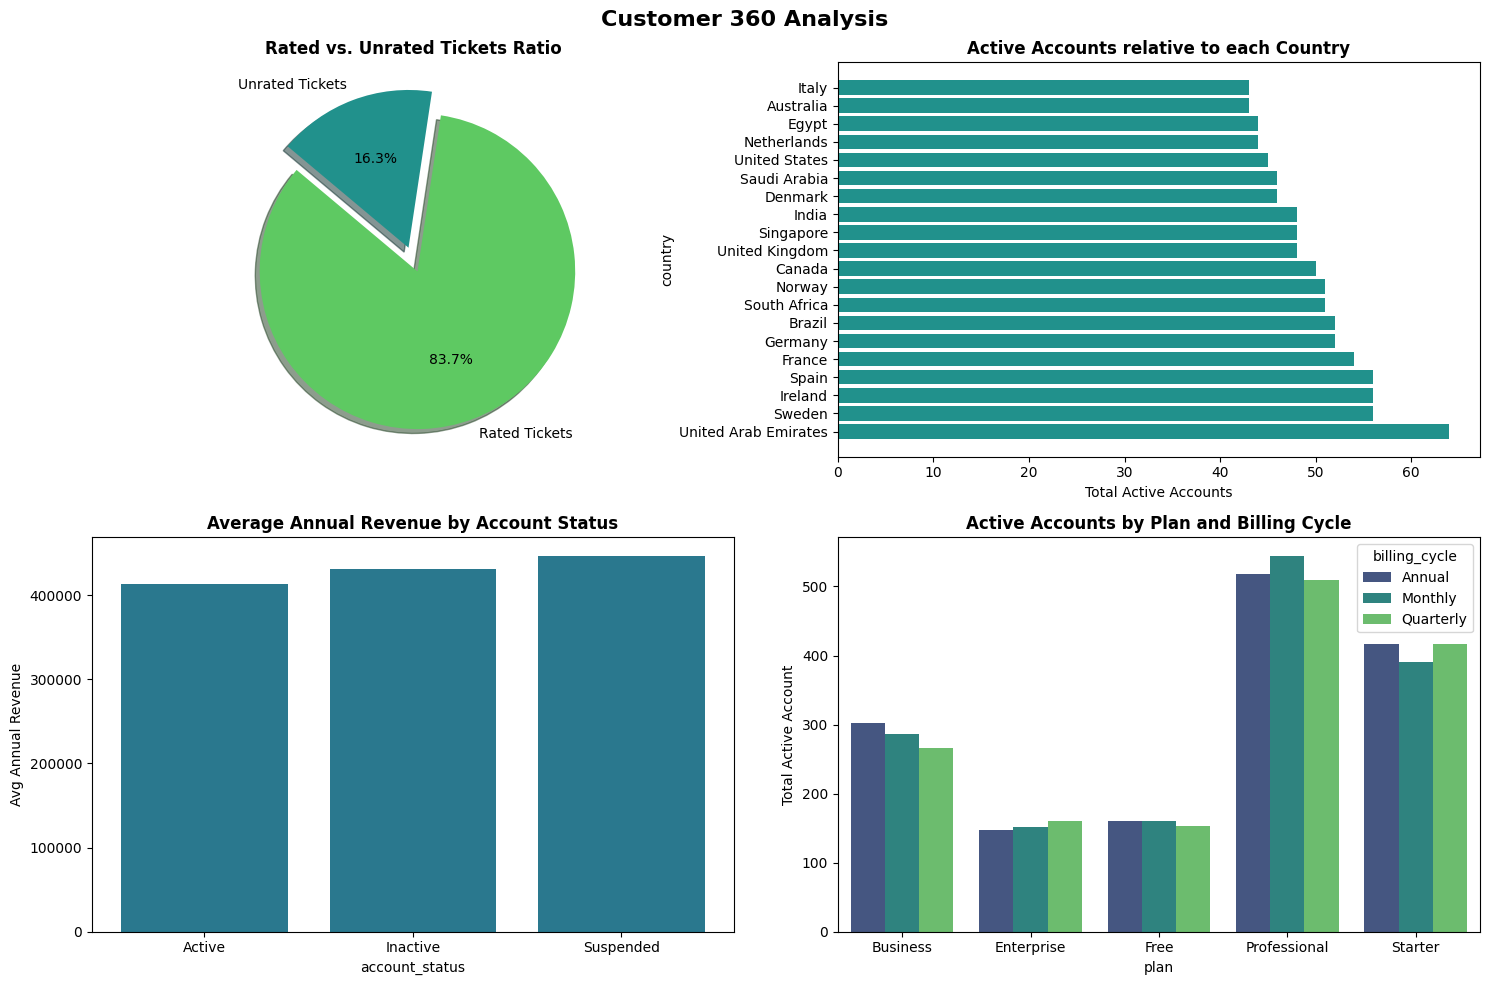

In [31]:
fig, viz = plt.subplots(2,2, figsize = (15,10))

fig.suptitle('Customer 360 Analysis', fontsize=16, fontweight='bold')

#Pie Chart for Rated and unrated tickets
viz[0,0].set_title('Rated vs. Unrated Tickets Ratio', fontsize=12, fontweight='bold')
viz[0,0].pie([rated_count, unrated_count], labels=['Rated Tickets', 'Unrated Tickets'], autopct='%1.1f%%', startangle=140, colors=['#5ec962',"#21918c"], shadow=True ,explode=(0.08, 0.08))


viz[0,1].barh(Q2['country'],Q2['Total Active Account'], color="#21918c")
#Title & Labels
viz[0,1].set_title('Active Accounts relative to each Country', fontsize=12, fontweight='bold')
viz[0,1].set_ylabel('country')
viz[0,1].set_xlabel('Total Active Accounts')


viz[1,0].bar(Q1['account_status'],Q1['Total Annual Revenue'] , color="#2a788e")
#Title & Labels
viz[1,0].set_title('Average Annual Revenue by Account Status', fontsize=12, fontweight='bold')
viz[1,0].set_ylabel('Avg Annual Revenue')
viz[1,0].set_xlabel('account_status')


viz[1,1] = sns.barplot(Q3, x='plan', y='Total Active Account', hue='billing_cycle', palette='viridis')
#Title & Labels
viz[1,1].set_title('Active Accounts by Plan and Billing Cycle', fontsize=12, fontweight='bold')
viz[1,1].set_ylabel('Total Active Account')
viz[1,1].set_xlabel('plan')

plt.tight_layout()
plt.show()

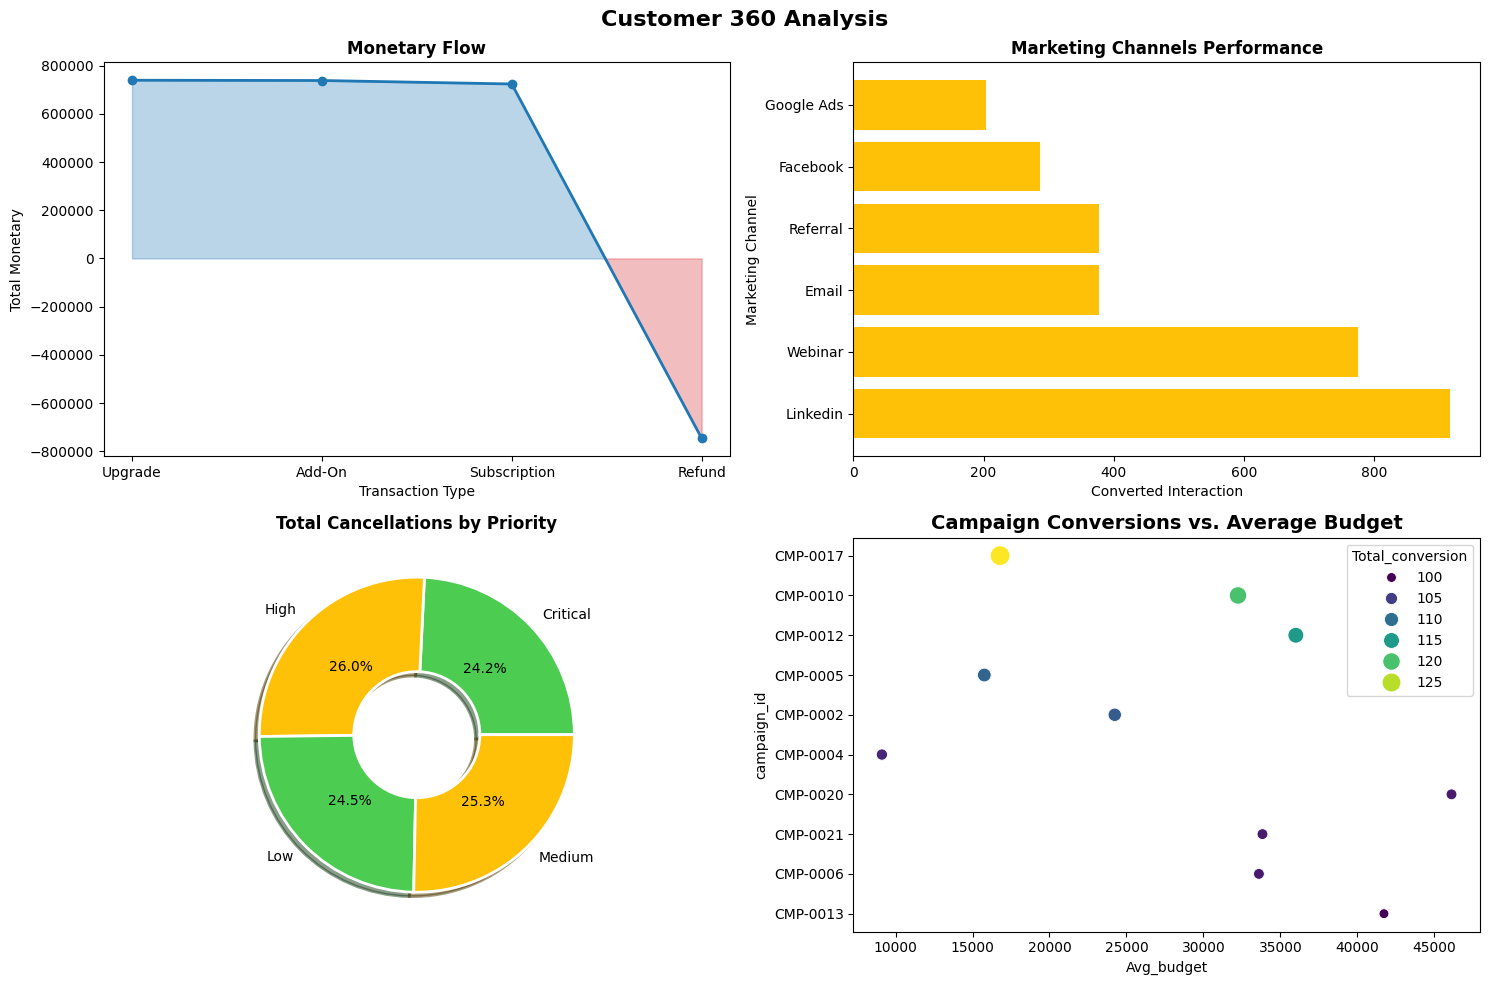

In [32]:
fig, viz = plt.subplots(2,2, figsize = (15,10))
fig.suptitle('Customer 360 Analysis', fontsize=16, fontweight='bold')

#]Draw Postive part
viz[0,0].fill_between(Q6['transaction_type'], Q6['Total monetary'], 0, where=(Q6['Total monetary'] >= 0), color='#1f77b4', alpha=0.3, interpolate=True)
#]Draw Negative part
viz[0,0].fill_between(Q6['transaction_type'], Q6['Total monetary'], 0, where=(Q6['Total monetary'] < 0), color='#d62728', alpha=0.3, interpolate=True)
#]Draw the line
viz[0,0].plot(Q6['transaction_type'], Q6['Total monetary'], color='#1f77b4', marker='o', linewidth=2, markersize=6)
#Title & Labels
viz[0,0].set_title('Monetary Flow', fontsize=12, fontweight='bold')
viz[0,0].set_ylabel('Total Monetary')
viz[0,0].set_xlabel('Transaction Type')


viz[0,1].barh(Q8['channel'],Q8['converted'] ,color='#FFC107')
#Title & Labels
viz[0,1].set_title('Marketing Channels Performance', fontsize=12, fontweight='bold')
viz[0,1].set_ylabel('Marketing Channel')
viz[0,1].set_xlabel('Converted Interaction')


viz[1,0].pie(Q9['Total_Cancell'], labels=Q9['priority'], autopct='%1.1f%%', colors=["#4CCC50", '#FFC107'], shadow=True ,wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
#Title
viz[1,0].set_title('Total Cancellations by Priority', fontsize=12, fontweight='bold')


viz[1,1] = sns.scatterplot(
    data=Q7, 
    x='Avg_budget', 
    y='campaign_id', 
    hue='Total_conversion', # Color of dots
    size='Total_conversion', # Size of dots
    sizes=(50, 200), 
    palette='viridis',
)
#Title
viz[1,1].set_title('Campaign Conversions vs. Average Budget', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<a id='conclusions'></a>
## **6. Conclusions**

### **Summary of Findings**
* **Account Status & Revenue:** Suspended accounts show slightly higher average annual revenue than active and inactive accounts.

* **Geographic Distribution:** The United Arab Emirates leads total active accounts, followed by countries like Sweden, Ireland, and Spain.

* **Subscription Preferences:** The Professional tier combined with monthly billing generates the highest active account volume.

* **Support Efficiency:** Rated tickets dominate support feedback at 83.7%, leaving unrated tickets at 16.3%.

* **Monetary Flow:** Upgrades, add-ons, and subscriptions drive positive financial flow, while refunds dip into negative values.

* **Marketing Channels:** LinkedIn and Webinars outperform other channels by delivering the highest converted interactions.

* **Campaign Efficiency:** Campaign CMP-0017 achieves the highest conversion rate (125) while maintaining an efficient budget under 20k.

### **Limitations**
* **Correlation, Not Causation:** Findings identify trends without proving direct causation for customer retention or profitability.

* **Missing Factors:** The analysis lacks external data such as macro_economic conditions and competitor pricing.

<a id='recommendations'></a>
## **7. Recommendations**

Based on the data analysis of our Customer 360 dataset, here are actionable recommendations to help business stakeholders improve customer retention, optimize marketing spend, and maximize revenue:

* **Reallocate Marketing Budget to High-ROI Campaigns:** Since Campaign CMP-0017 achieves the highest conversion rate (125) while maintaining an efficient budget under 20k, management should study its success factors and shift promotional funds away from underperforming, high-cost campaigns.

* **Capitalize on Top-Performing Acquisition Channels:** Given that LinkedIn and Webinars outperform other acquisition channels in delivered interactions, marketing teams should increase content and resource allocation toward these high-yield touchpoints.

* **Target High-Value Subscription Tiers:** Focus retention and upselling efforts on the Professional and Starter tiers—especially those utilizing monthly billing cycles—by introducing targeted engagement incentives and streamlined renewal workflows to protect our largest active user bases.

* **Audit Suspended Account Revenue Patterns:** Investigate why suspended accounts show slightly higher average annual revenue compared to active and inactive profiles to uncover potential retention and reactivation strategies.

* **Streamline Feedback and Support Engagement:** Capitalize on the strong 83.7% rating rate by analyzing customer feedback insights from rated support tickets to further enhance service delivery, while implementing gentle follow-up prompts to capture data from the remaining unrated interactions.